In [1]:
import pandas as pd
data=pd.read_csv("advertising.csv")
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [3]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
data.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [5]:
data.shape

(200, 4)

In [6]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [10]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [11]:
data.duplicated().sum()

0

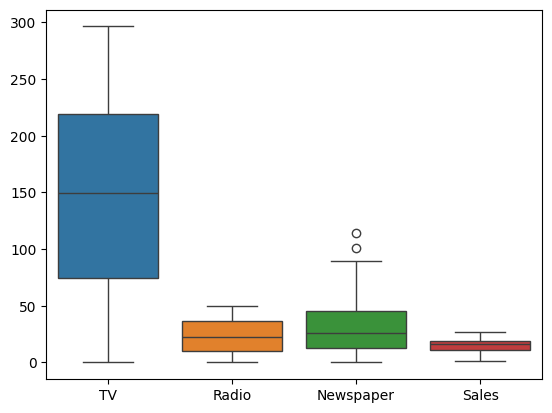

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(data=data)
plt.show()

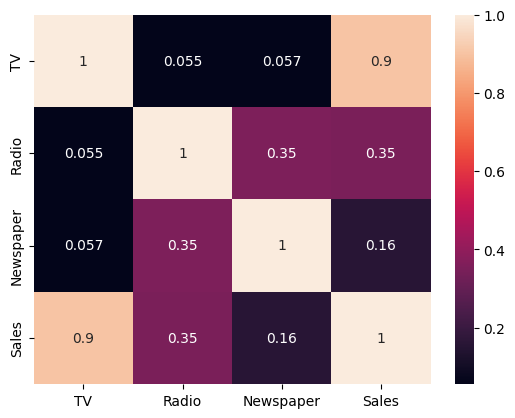

In [13]:
data.corr()
sns.heatmap(data.corr(), annot=True)
plt.show()

In [15]:
X=data[['TV']]
y=data[['Sales']]

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test

(        TV
 79   116.0
 197  177.0
 38    43.1
 24    62.3
 122  224.0
 ..     ...
 106   25.0
 14   204.1
 92   217.7
 179  165.6
 102  280.2
 
 [160 rows x 1 columns],
         TV
 95   163.3
 15   195.4
 30   292.9
 158   11.7
 128  220.3
 115   75.1
 69   216.8
 170   50.0
 174  222.4
 45   175.1
 66    31.5
 182   56.2
 165  234.5
 78     5.4
 186  139.5
 177  170.2
 56     7.3
 152  197.6
 82    75.3
 68   237.4
 124  229.5
 16    67.8
 148   38.0
 93   250.9
 65    69.0
 60    53.5
 84   213.5
 67   139.3
 125   87.2
 132    8.4
 9    199.8
 18    69.2
 55   198.9
 75    16.9
 150  280.7
 104  238.2
 135   48.3
 137  273.7
 164  117.2
 76    27.5)

In [17]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)

Slope (m): [0.05548294]
Intercept (c): [7.00710843]


In [18]:
y_pred=model.predict(X_test)
y_pred

array([[16.06747317],
       [17.84847567],
       [23.25806271],
       [ 7.65625887],
       [19.23000098],
       [11.17387752],
       [19.03581067],
       [ 9.78125562],
       [19.34651516],
       [16.72217191],
       [ 8.75482116],
       [10.12524988],
       [20.01785878],
       [ 7.30671633],
       [14.74697911],
       [16.45030549],
       [ 7.41213392],
       [17.97053815],
       [11.18497411],
       [20.17875932],
       [19.74044406],
       [10.76885203],
       [ 9.1154603 ],
       [20.92777906],
       [10.83543156],
       [ 9.97544593],
       [18.85271696],
       [14.73588252],
       [11.84522114],
       [ 7.47316516],
       [18.09260063],
       [10.84652815],
       [18.04266598],
       [ 7.94477018],
       [22.58117079],
       [20.22314567],
       [ 9.68693462],
       [22.19279018],
       [13.50970946],
       [ 8.53288939]])

In [19]:
new_pred=pd.DataFrame([[150]],columns=['TV'])
predicted=model.predict(new_pred)
print("For TV 150 units predicted value:",predicted)

For TV 150 units predicted value: [[15.32955002]]


In [20]:
from sklearn.metrics import mean_squared_error, r2_score
 
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
r2=r2_score(y_test,y_pred)
print("r2 score :",r2)

Mean Squared Error: 6.101072906773963
r2 score : 0.802561303423698


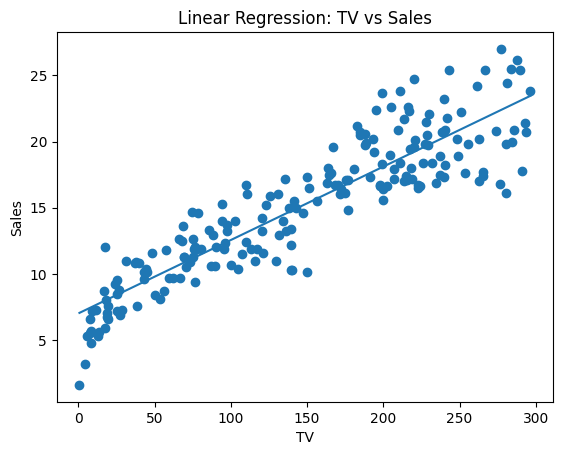

In [21]:
import matplotlib.pyplot as plt
import numpy as np
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_line_df = pd.DataFrame(X_line, columns=['TV'])
y_line = model.predict(X_line_df)

plt.figure()
plt.scatter(X, y)
plt.plot(X_line, y_line)
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("Linear Regression: TV vs Sales")
plt.show()